In [49]:
%matplotlib inline

import gym
import itertools
import matplotlib
import numpy as np
import sys
import sklearn.pipeline
import sklearn.preprocessing

if "../" not in sys.path:
  sys.path.append("../") 

from lib import plotting
from sklearn.linear_model import SGDRegressor
from sklearn.kernel_approximation import RBFSampler

matplotlib.style.use('ggplot')

In [50]:
env = gym.envs.make("MountainCar-v0")

In [ ]:
# Feature Preprocessing: Normalize to zero mean and unit variance
# We use a few samples from the observation space to do this
# 随机采样 10000 个状态，来估计状态空间的均值和方差，以便后续对状态进行标准化处理
# (让后面的 featurizer 理解原始状态空间是怎样，以更好的编码状态特征)
observation_examples = np.array([env.observation_space.sample() for x in range(10000)])
scaler = sklearn.preprocessing.StandardScaler()
scaler.fit(observation_examples)


# 原始状态 (pos,vel) 是一个二维向量，直接对其用线性模型来拟合 Q(s,a) 是不够的，因为 Q 函数是强非线性的
# 因此，将原始状态映射为一个高维特征，再去用线性模型来拟合 Q(s,a)，就有可能拟合出一个非线性的函数了
# state → 非线性映射 φ(s) → 线性模型
# # 原始 RBF 核
# RBF 核函数是一种常用的非线性映射方法，它将输入空间映射到一个高维特征空间，使得在这个特征空间中，原本非线性的关系变得线性可分。
# RBF 核函数的公式为：φ(s) = exp(-γ * ||s - c||^2)
# 其中，s 是输入状态，c 是一个中心点，γ 是一个参数控制函数的宽度。通过选择不同的中心点和 γ 参数，可以得到不同的特征表示。
# 这里本质是 计算 原始状态s与多个参考中心点c的距离（相似度），利用这些距离作为特征来表示状态
# γ 控制了距离的敏感度(感受范围），γ 越大，越局部，距离越近的状态特征值越大，γ 越小，越平滑，距离较远的状态特征值也会较大。

# 这里实际使用的 RBF 核是通过 sklearn 的 RBFSampler 来实现的，它使用随机 Fourier 特征来近似 RBF 核函数，从而将输入状态映射到一个高维特征空间中。
# φ_i(x) = cos(w_i · x + b_i) 
# 我们使用了四个不同 γ 参数的 RBF 核，每个核生成 100 维特征，总共得到 400 维的特征表示。这些特征可以更好地捕捉状态空间中的非线性关系，从而提高线性模型拟合 Q 函数的能力。
# Used to convert a state to a featurized representation.
# We use RBF kernels with different variances to cover different parts of the space
# 2维->400维 （4个RBF核，每个核100维）
featurizer = sklearn.pipeline.FeatureUnion([
        ("rbf1", RBFSampler(gamma=5.0, n_components=100)),
        ("rbf2", RBFSampler(gamma=2.0, n_components=100)),
        ("rbf3", RBFSampler(gamma=1.0, n_components=100)),
        ("rbf4", RBFSampler(gamma=0.5, n_components=100))
        ])
featurizer.fit(scaler.transform(observation_examples))

FeatureUnion(transformer_list=[('rbf1', RBFSampler(gamma=5.0)),
                               ('rbf2', RBFSampler(gamma=2.0)),
                               ('rbf3', RBFSampler()),
                               ('rbf4', RBFSampler(gamma=0.5))])

In [ ]:
class Estimator():
    """
    Value Function approximator. 
    """
    
    def __init__(self):
        # We create a separate model for each action in the environment's
        # action space. Alternatively we could somehow encode the action
        # into the features, but this way it's easier to code up.
        self.models = []
        for _ in range(env.action_space.n):
            model = SGDRegressor(learning_rate="constant")
            # We need to call partial_fit once to initialize the model
            # or we get a NotFittedError when trying to make a prediction
            # This is quite hacky.
            # 初始化模型参数，这里用一个状态的特征和一个任意的目标值来进行初始化
            model.partial_fit([self.featurize_state(env.reset())], [0])
            self.models.append(model)
    
    def featurize_state(self, state):
        """
        Returns the featurized representation for a state.
        """
        scaled = scaler.transform([state])
        featurized = featurizer.transform(scaled)
        return featurized[0]
    
    def predict(self, s, a=None):
        """
        Makes value function predictions.
        
        Args:
            s: state to make a prediction for
            a: (Optional) action to make a prediction for
            
        Returns
            If an action a is given this returns a single number as the prediction.
            If no action is given this returns a vector or predictions for all actions
            in the environment where pred[i] is the prediction for action i.
            
        """
        # TODO: Implement this!
        # state -> feature
        features = self.featurize_state(s)
        if a is None:
            # return 所有可能动作的 Q(s,a) 线性模型的预测值
            return np.array([m.predict([features])[0] for m in self.models])
            # sklearn 需要的输入(n_samples, n_features)，输出是 (n_samples,) 
            # 我们只预测一个状态 n_samples=1, 
            # 所以输入需要 [features]，输出取 [0]，同理后面的 [y] 也是一样的
        else:
            # return 该动作 a 的 Q(s,a) 线性模型的预测值
            return self.models[a].predict([features])[0]
    
    def update(self, s, a, y):
        """
        Updates the estimator parameters for a given state and action towards
        the target y.
        """
        # TODO: Implement this!
        # state -> feature
        features = self.featurize_state(s)
        # 更新 该动作 a 的 Q(s,a) 线性模型的参数，使得模型预测值更接近目标 y
        self.models[a].partial_fit([features], [y])
        return None

In [53]:
def make_epsilon_greedy_policy(estimator, epsilon, nA):
    """
    Creates an epsilon-greedy policy based on a given Q-function approximator and epsilon.
    
    Args:
        estimator: An estimator that returns q values for a given state
        epsilon: The probability to select a random action . float between 0 and 1.
        nA: Number of actions in the environment.
    
    Returns:
        A function that takes the observation as an argument and returns
        the probabilities for each action in the form of a numpy array of length nA.
    
    """
    def policy_fn(observation):
        A = np.ones(nA, dtype=float) * epsilon / nA
        q_values = estimator.predict(observation)
        best_action = np.argmax(q_values)
        A[best_action] += (1.0 - epsilon)
        return A
    return policy_fn

In [54]:
def q_learning(env, estimator, num_episodes, discount_factor=1.0, epsilon=0.1, epsilon_decay=1.0):
    """
    Q-Learning algorithm for off-policy TD control using Function Approximation.
    Finds the optimal greedy policy while following an epsilon-greedy policy.
    
    Args:
        env: OpenAI environment.
        estimator: Action-Value function estimator
        num_episodes: Number of episodes to run for.
        discount_factor: Gamma discount factor.
        epsilon: Chance the sample a random action. Float betwen 0 and 1.
        epsilon_decay: Each episode, epsilon is decayed by this factor
    
    Returns:
        An EpisodeStats object with two numpy arrays for episode_lengths and episode_rewards.
    """

    # Keeps track of useful statistics
    stats = plotting.EpisodeStats(
        episode_lengths=np.zeros(num_episodes),
        episode_rewards=np.zeros(num_episodes))    
    
    for i_episode in range(num_episodes):
        
        # The policy we're following
        policy = make_epsilon_greedy_policy(
            estimator, epsilon * epsilon_decay**i_episode, env.action_space.n)
        
        # Print out which episode we're on, useful for debugging.
        # Also print reward for last episode
        last_reward = stats.episode_rewards[i_episode - 1]
        print("\rEpisode {}/{} ({})".format(i_episode + 1, num_episodes, last_reward), end="")
        sys.stdout.flush()
        
        # TODO: Implement this!
        state = env.reset()
        for t in itertools.count():
            # get action probabilities and choose an action while following epsilon-greedy policy
            action_probs = policy(state)
            action = np.random.choice(np.arange(len(action_probs)), p=action_probs)

            # take a step and update statistics
            next_state, reward, done, _ = env.step(action)
            stats.episode_rewards[i_episode] += reward
            stats.episode_lengths[i_episode] = t

            # Q-learning update
            # choose next action using greedy policy
            q_values_next = estimator.predict(next_state)
            # TD target
            td_target = reward + discount_factor * np.max(q_values_next)

            # update function approximator using our target
            estimator.update(state, action, td_target)

            print("\rStep {} @ Episode {}/{} ({})".format(t, i_episode + 1, num_episodes, last_reward), end="")

            if done:
                break
            state = next_state
    return stats

In [55]:
estimator = Estimator()

In [56]:
# Note: For the Mountain Car we don't actually need an epsilon > 0.0
# because our initial estimate for all states is too "optimistic" which leads
# to the exploration of all states.
stats = q_learning(env, estimator, 100, epsilon=0.0)

Step 133 @ Episode 100/100 (-128.0)

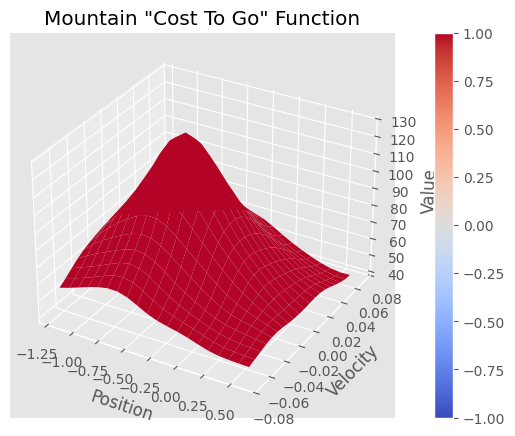

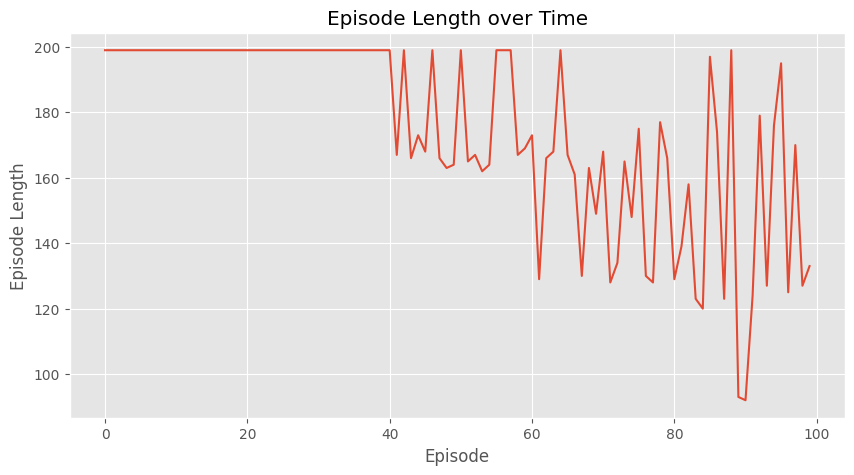

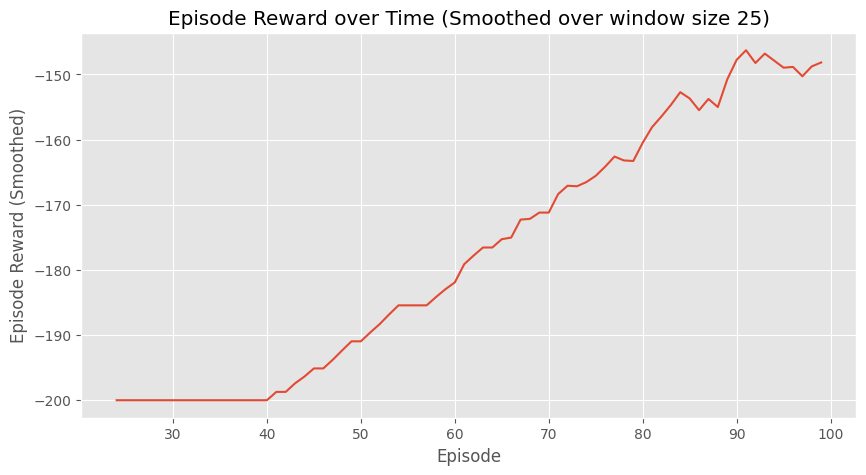

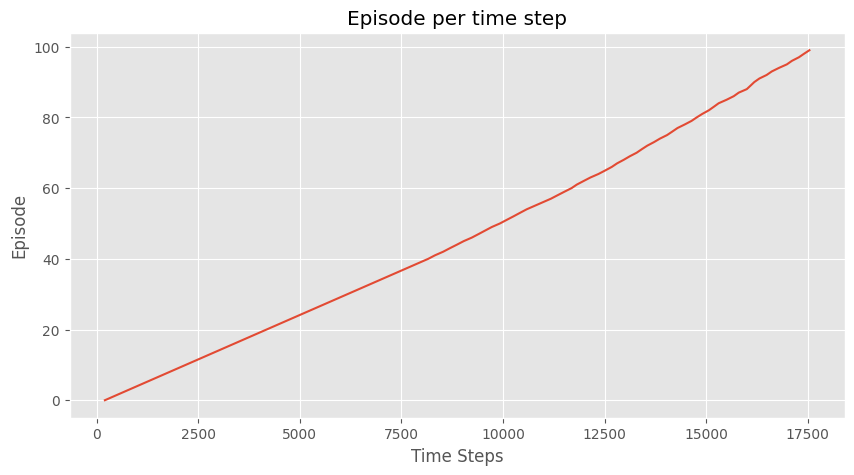

(<Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>)

In [57]:
plotting.plot_cost_to_go_mountain_car(env, estimator)
plotting.plot_episode_stats(stats, smoothing_window=25)